## Импорты

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy import signal
from scipy.io import loadmat
import scipy.io as sio
from numpy.fft import fft, fftfreq
import scipy.fftpack

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8')

## Пункт 1

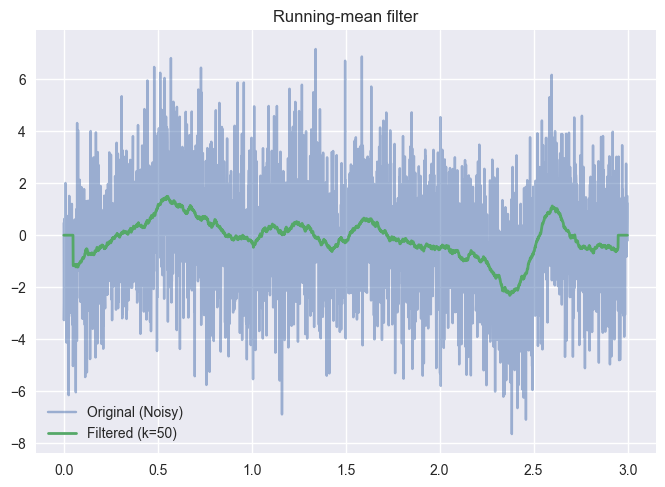

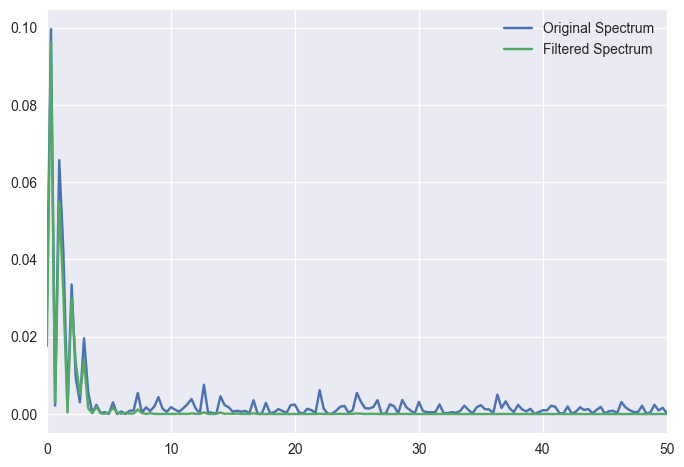

In [6]:
# Создание зашумленного сигнала
srate = 1000
time = np.arange(0, 3, 1/srate)
n = len(time)
p = 15 # количество гармоник
signal_orig = np.interp(np.linspace(0, p, n), np.arange(0, p), np.random.randn(p))
noise = np.random.randn(n) * 2
x = signal_orig + noise

# Реализация фильтра (Формула 1)
k = 50 # параметр окна
y = np.zeros(n)
for t in range(k, n-k):
    y[t] = np.mean(x[t-k : t+k+1])

# Визуализация
plt.plot(time, x, label='Original (Noisy)', alpha=0.5)
plt.plot(time, y, label=f'Filtered (k={k})', linewidth=2)
plt.title('Running-mean filter')
plt.legend()
plt.show()

# Вывод спектра
hz = np.linspace(0, srate/2, int(n/2)+1)
x_fft = np.abs(scipy.fftpack.fft(x)/n)**2
y_fft = np.abs(scipy.fftpack.fft(y)/n)**2
plt.plot(hz, x_fft[:len(hz)], label='Original Spectrum')
plt.plot(hz, y_fft[:len(hz)], label='Filtered Spectrum')
plt.xlim([0, 50])
plt.legend()
plt.show()

Этот фильтр заменяет каждое значение сигнала средним арифметическим его соседей в окне шириной 2k+1.
На временном графике отфильтрованный сигнал более гладкий, очищенный от шума. В спектре видим подавление высоких частот, так как усреднение работает как фильтр низких частот (ФНЧ)

## Пункт 2

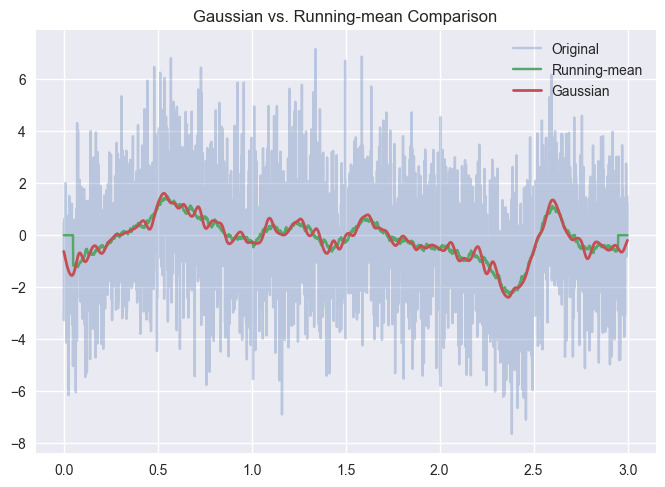

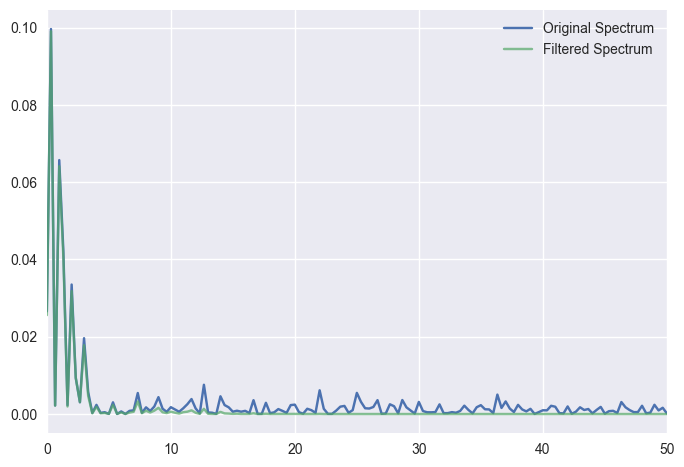

In [17]:

fwhm = 40 # full-width at half maximum в мс
k = 100
gtime = np.arange(-k, k)
# Формула Гаусса (Фор. 2)
gauss_win = np.exp(-4 * np.log(2) * gtime**2 / fwhm**2)
gauss_win = gauss_win / np.sum(gauss_win) # нормировка

# Свертка 
y_gauss = np.convolve(x, gauss_win, mode='same')

plt.plot(time, x, alpha=0.3, label='Original')
plt.plot(time, y, label='Running-mean')
plt.plot(time, y_gauss, label='Gaussian', linewidth=2)
plt.title('Gaussian vs. Running-mean Comparison')
plt.legend()
plt.show()

hz = np.linspace(0, srate/2, int(n/2)+1)
x_fft = np.abs(scipy.fftpack.fft(x)/n)**2
y_fft = np.abs(scipy.fftpack.fft(y)/n)**2
y_fft_gauss = np.abs(scipy.fftpack.fft(y_gauss)/n)**2
plt.plot(hz, x_fft[:len(hz)], label='Original Spectrum')
#plt.plot(hz, y_fft[:len(hz)], label='Filtered Spectrum')
plt.plot(hz, y_fft_gauss[:len(hz)], label='Filtered Spectrum', alpha = 0.7)
plt.xlim([0, 50])
plt.legend()
plt.show()

Здесь используется взвешенное среднее, где веса определяются функцией Гаусса. Это позволяет избежать резких ступенек обычного усреднения.
Фильтр Гаусса дает более гадкую кривую по сравнению со скользящим средним. Спектр очищенного сигнала имеет более плавный спад на высоких частотах.

## Пункт 3

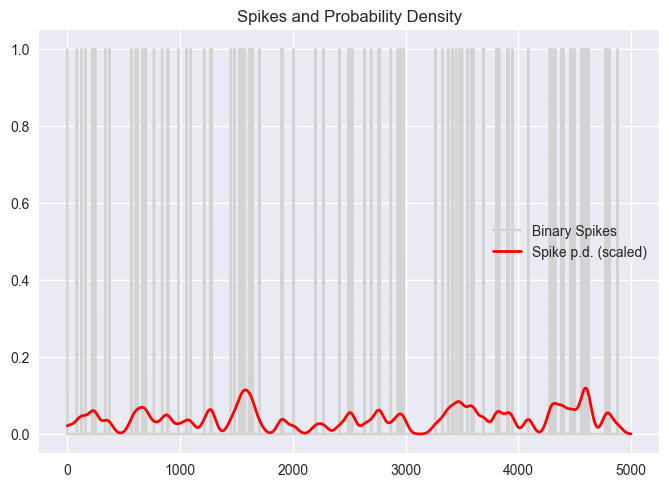

In [26]:

n_spikes = 5000
spikes = np.zeros(n_spikes)
spike_idx = np.random.choice(range(n_spikes), 100, replace=False)
spikes[spike_idx] = 1

fwhm_spike = 100 
g_spike_time = np.arange(-150, 150)
gauss_spike = np.exp(-4 * np.log(2) * g_spike_time**2 / fwhm_spike**2)
gauss_spike = gauss_spike / np.sum(gauss_spike)

spike_pd = np.convolve(spikes, gauss_spike, mode='same')

plt.figure()
plt.plot(spikes, color='lightgray', label='Binary Spikes')

plt.plot(spike_pd * 2, color='red', linewidth=2, label='Spike p.d. (scaled)')
plt.title('Spikes and Probability Density')
plt.legend()
plt.show()

Сигнал состоит из редких импульсов амплитудой A=1V. Мы применяем сглаживание по Гауссу, чтобы получить плотность вероятности или интенсивность этих всплесков.
Вместо отдельных вертикальных линий мы видим плавную кривую, которая показывает, в каких участках времени плотность пиков выше.

## Пункт 4

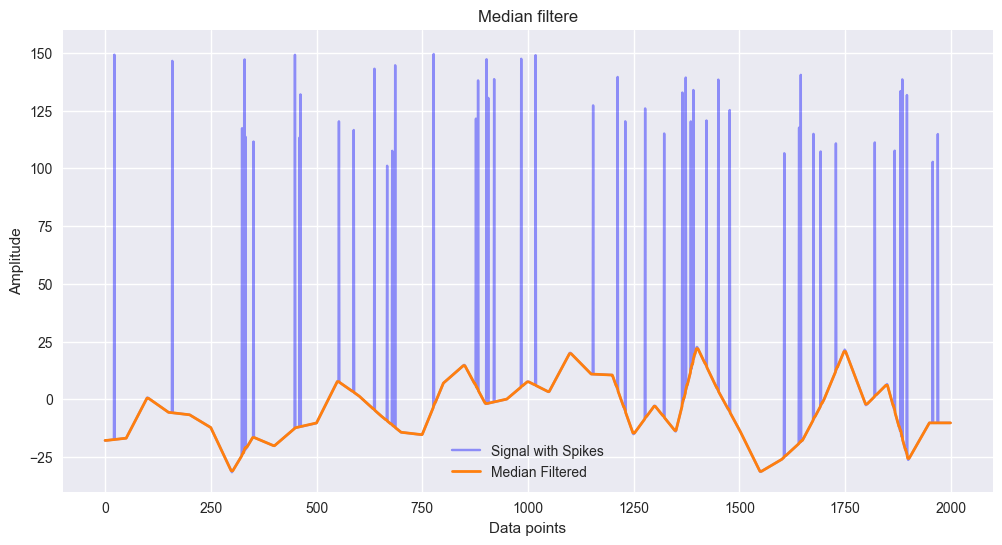

In [52]:
n = 2000
p = 40 

signal_base = np.interp(np.linspace(0, p, n), np.arange(0, p), np.random.randn(p)) * 15


x_spiky = signal_base.copy()
n_outliers = 50
outlier_idx = np.random.choice(range(n), n_outliers)

x_spiky[outlier_idx] = np.random.uniform(100, 150, n_outliers) 


limit = 80
x_thresholded = x_spiky.copy()
x_thresholded[x_thresholded > limit] = np.nan 


y_median = signal.medfilt(x_spiky, kernel_size=7)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(x_spiky, color='blue', alpha=0.4, label='Signal with Spikes')
plt.plot(y_median, color='#ff7f0e', linewidth=2, label='Median Filtered')

plt.title('Median filtere')
plt.xlabel('Data points')
plt.ylabel('Amplitude')
plt.legend()
plt.ylim([-40, 160]) # Фиксируем масштаб как на Рис. 4 
plt.show()

## Пункт 5

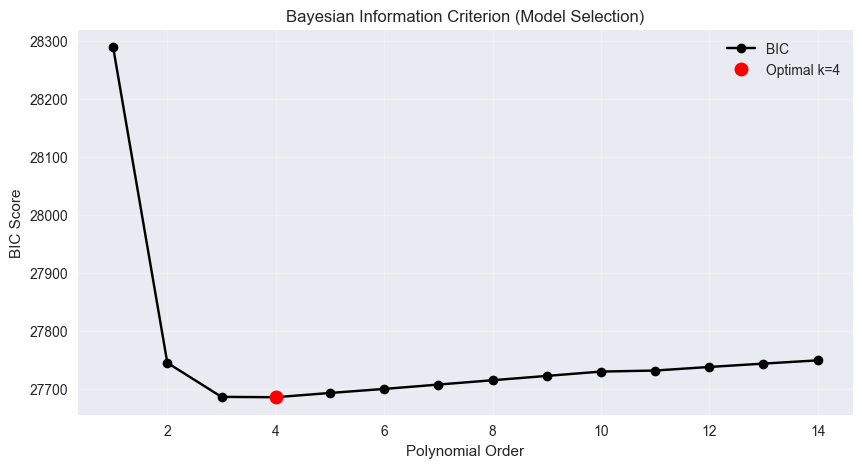

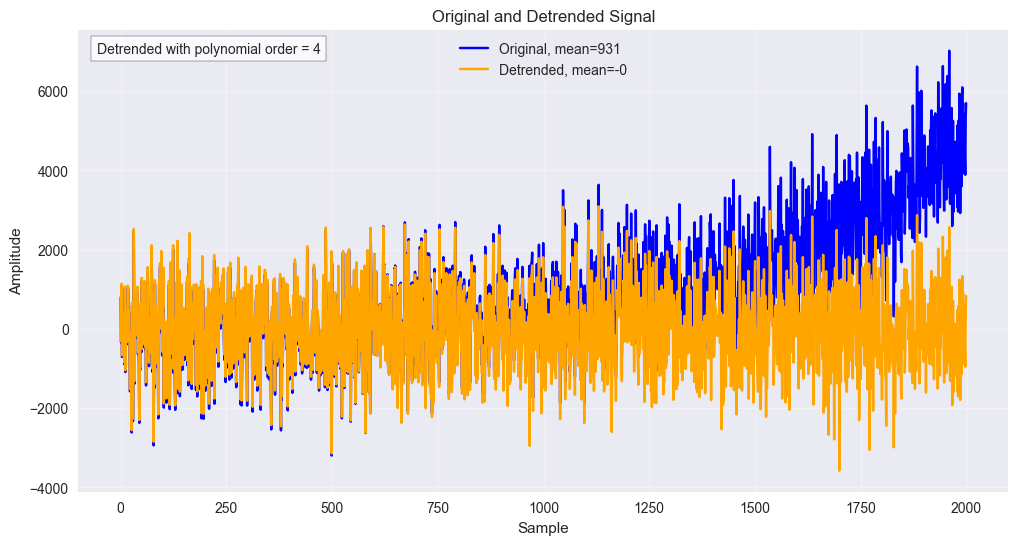

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Генерируем данные (сигнал + сильный изгиб)
# Увеличим количество точек до ~2000, чтобы график был похож на Рис. 6
n = 2000
x = np.linspace(0, 10, n)
trend = 0.5 * x**4 - 2 * x**2 + x          # Тренд 4-й степени (можно менять)
y = trend + np.random.randn(n) * 10       # Сильный шум

orders = np.arange(1, 15)
bic_values = []

for k in orders:
    poly = np.polyfit(x, y, k)
    y_hat = np.polyval(poly, x)
    resid = y - y_hat
    sigma2 = np.var(resid)
   
    # Классический BIC (точно по формуле из задания)
    bic = n * np.log(sigma2) + k * np.log(n)
    bic_values.append(bic)

# Находим оптимальный порядок
best_k = orders[np.argmin(bic_values)]

# === 1. График BIC (уже был у тебя — оставляем «красивым») ===
plt.figure(figsize=(10, 5))
plt.plot(orders, bic_values, 'o-', color='black', label='BIC')
plt.plot(best_k, bic_values[np.argmin(bic_values)], 'ro', markersize=10, 
         label=f'Optimal k={best_k}')

plt.title('Bayesian Information Criterion (Model Selection)')
plt.xlabel('Polynomial Order')
plt.ylabel('BIC Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# === 2. НОВЫЙ ГРАФИК — оригинальный и детрендированный сигнал (Рис. 6) ===
# Фитим полином лучшего порядка и вычитаем тренд
poly_coeffs = np.polyfit(x, y, best_k)
y_trend = np.polyval(poly_coeffs, x)
detrended = y - y_trend

# Визуализация точно в стиле Рис. 6
plt.figure(figsize=(12, 6))
plt.plot(y, color='blue', label=f'Original, mean={np.mean(y):.0f}')
plt.plot(detrended, color='orange', label=f'Detrended, mean={np.mean(detrended):.0f}')

plt.title('Original and Detrended Signal')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# Дополнительно можно подписать оптимальный порядок
plt.text(0.02, 0.95, f'Detrended with polynomial order = {best_k}', 
         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

## Пункт 6